In [1]:
#Objective: Analyze NYC taxi trip data to identify ride demand patterns, peak hours, trip characteristics and fare behavior.

In [4]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [5]:
#file import
filename = "taxi_tripdata.csv"
df = pd.read_csv(filename)

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_3384\492305250.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


In [13]:
#understand data structure
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83691 entries, 0 to 83690
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               51173 non-null  float64
 1   lpep_pickup_datetime   83691 non-null  object 
 2   lpep_dropoff_datetime  83691 non-null  object 
 3   store_and_fwd_flag     51173 non-null  object 
 4   RatecodeID             51173 non-null  float64
 5   PULocationID           83691 non-null  int64  
 6   DOLocationID           83691 non-null  int64  
 7   passenger_count        51173 non-null  float64
 8   trip_distance          83691 non-null  float64
 9   fare_amount            83691 non-null  float64
 10  extra                  83691 non-null  float64
 11  mta_tax                83691 non-null  float64
 12  tip_amount             83691 non-null  float64
 13  tolls_amount           83691 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,0.5,0.5,0.00,0.0,NaN,0.3,7.30,2.0,1.0,0.0
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,0.5,0.5,0.00,0.0,NaN,0.3,43.30,2.0,1.0,0.0
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,0.5,0.5,2.34,0.0,NaN,0.3,10.14,1.0,1.0,0.0
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0,0.0
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,0.5,0.5,0.00,0.0,NaN,0.3,8.30,2.0,1.0,0.0


In [15]:
df.shape

(83691, 20)

In [12]:
for col in mixed_cols:
    print(df[col].value_counts())
    

lpep_pickup_datetime
2021-07-19 12:38:00    9
2021-07-31 09:02:00    9
2021-07-28 11:25:00    8
2021-07-07 09:28:00    8
2021-07-07 09:20:00    8
                      ..
2021-07-15 13:48:29    1
2021-07-15 13:14:54    1
2021-07-15 14:34:04    1
2021-07-15 14:36:26    1
2021-07-02 07:58:00    1
Name: count, Length: 69694, dtype: int64
lpep_dropoff_datetime
2021-07-21 13:27:00    8
2021-07-06 09:43:00    7
2021-07-29 10:00:00    7
2021-07-13 08:56:00    7
2021-07-08 12:44:00    7
                      ..
2021-07-15 15:59:18    1
2021-07-15 15:02:52    1
2021-07-15 14:37:43    1
2021-07-15 14:10:47    1
2021-07-02 08:30:00    1
Name: count, Length: 69832, dtype: int64
store_and_fwd_flag
N    50977
Y      196
Name: count, dtype: int64


In [17]:
#data cleaning
#missing values and duplicates
df.isnull().sum()

VendorID                 32518
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       32518
RatecodeID               32518
PULocationID                 0
DOLocationID                 0
passenger_count          32518
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                83691
improvement_surcharge        0
total_amount                 0
payment_type             32518
trip_type                32518
congestion_surcharge     32518
dtype: int64

In [18]:
df.duplicated().sum()

0

In [19]:
df =df.drop(columns=["ehail_fee"])

In [21]:
df.shape

(83691, 19)

In [23]:
#check if rows are blank all through

#list of columns to check
cols_check =['VendorID','congestion_surcharge','trip_type','payment_type','passenger_count','RatecodeID','store_and_fwd_flag']

#select rows where any of these columns are missing
missing_rows = df[df[cols_check].isna().any(axis=1)]

#check if all columns are missing in these rows
all_missing = missing_rows[cols_check].isna().all(axis=1)

#show counts
print('Rows with any missing in selected columns', missing_rows.shape[0])
print('Rows where all these columns are missing:', all_missing.sum())

Rows with any missing in selected columns 32518
Rows where all these columns are missing: 32518


In [24]:
#dropping completely blank rows
df = df[~df[cols_check].isna().all(axis=1)]
df.shape

(51173, 19)

In [25]:
df.isnull().sum()

VendorID                 0
lpep_pickup_datetime     0
lpep_dropoff_datetime    0
store_and_fwd_flag       0
RatecodeID               0
PULocationID             0
DOLocationID             0
passenger_count          0
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
payment_type             0
trip_type                0
congestion_surcharge     0
dtype: int64

In [26]:
#checking data types
df.dtypes

VendorID                 float64
lpep_pickup_datetime      object
lpep_dropoff_datetime     object
store_and_fwd_flag        object
RatecodeID               float64
PULocationID               int64
DOLocationID               int64
passenger_count          float64
trip_distance            float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
payment_type             float64
trip_type                float64
congestion_surcharge     float64
dtype: object

In [27]:
#convert datetime columns to date time datatype
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

df[["lpep_dropoff_datetime","lpep_pickup_datetime"]].head()

,lpep_dropoff_datetime,lpep_pickup_datetime
0,2021-07-01 00:35:36,2021-07-01 00:30:52
1,2021-07-01 01:01:31,2021-07-01 00:25:36
2,2021-07-01 00:12:00,2021-07-01 00:05:58
3,2021-07-01 00:47:23,2021-07-01 00:41:40
4,2021-07-01 00:58:46,2021-07-01 00:51:32


In [36]:
df['start_hour'] = df['lpep_pickup_datetime'].dt.hour
df['start_day'] = df['lpep_pickup_datetime'].dt.day
df['start_weekday'] = df['lpep_pickup_datetime'].dt.day_name()
df['start_month'] = df['lpep_pickup_datetime'].dt.month
df[['start_hour','start_day','start_weekday','start_month']].head(10)

,start_hour,start_day,start_weekday,start_month
0,0,1,Thursday,7
1,0,1,Thursday,7
2,0,1,Thursday,7
3,0,1,Thursday,7
4,0,1,Thursday,7
5,0,1,Thursday,7
6,0,1,Thursday,7
7,0,1,Thursday,7
8,0,1,Thursday,7
9,0,1,Thursday,7


In [39]:
df['trip_duration_minutes']=(df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds()/60

In [40]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,start_hour,start_day,start_weekday,start_month,trip_duration_minutes
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,...,0.3,7.30,2.0,1.0,0.0,0,1,Thursday,7,4.733333
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,...,0.3,43.30,2.0,1.0,0.0,0,1,Thursday,7,35.916667
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,...,0.3,10.14,1.0,1.0,0.0,0,1,Thursday,7,6.033333
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,...,0.3,7.80,2.0,1.0,0.0,0,1,Thursday,7,5.716667
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,...,0.3,8.30,2.0,1.0,0.0,0,1,Thursday,7,7.233333


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_3384\1190708706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index,y=hourly_counts.values,palette='viridis')


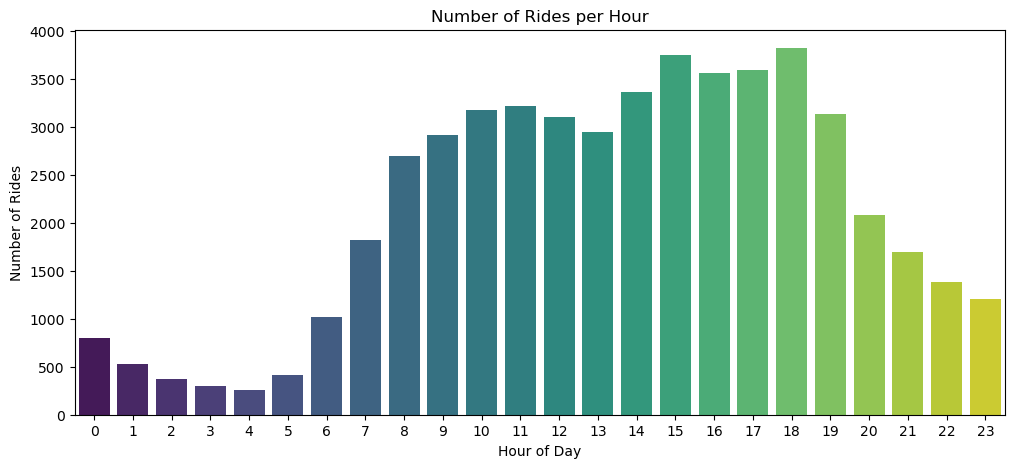

In [45]:
#trips per hour
hourly_counts = df['start_hour'].value_counts().sort_index()

#plot
plt.figure(figsize=(12,5))
sns.barplot(x=hourly_counts.index,y=hourly_counts.values,palette='viridis')
plt.title("Number of Rides per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.show()

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_3384\3379605834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_counts.index,y=weekday_counts, palette='magma')


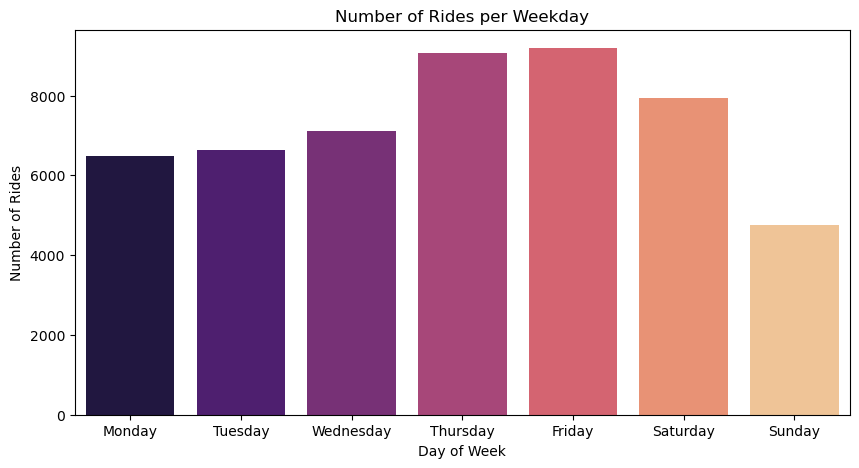

In [49]:
#busiest days
weekday_counts = df['start_weekday'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_counts.index,y=weekday_counts, palette='magma')
plt.title('Number of Rides per Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.show()

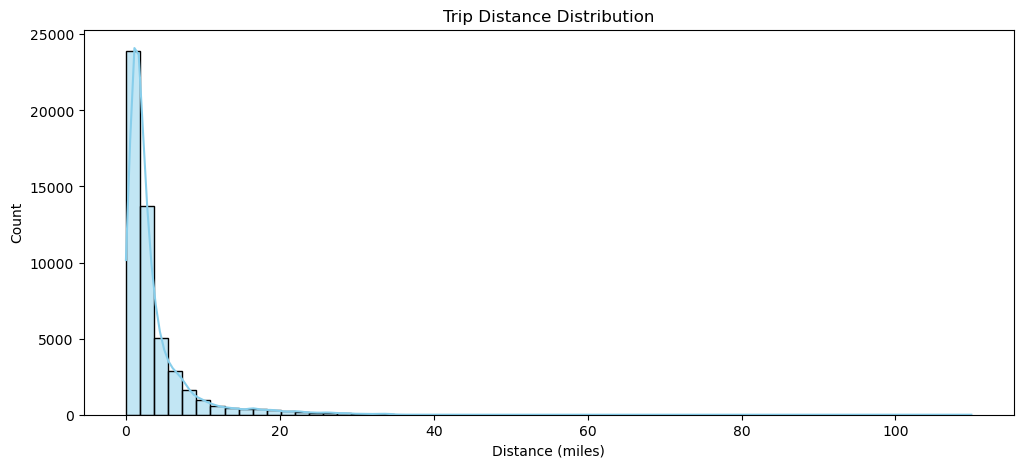

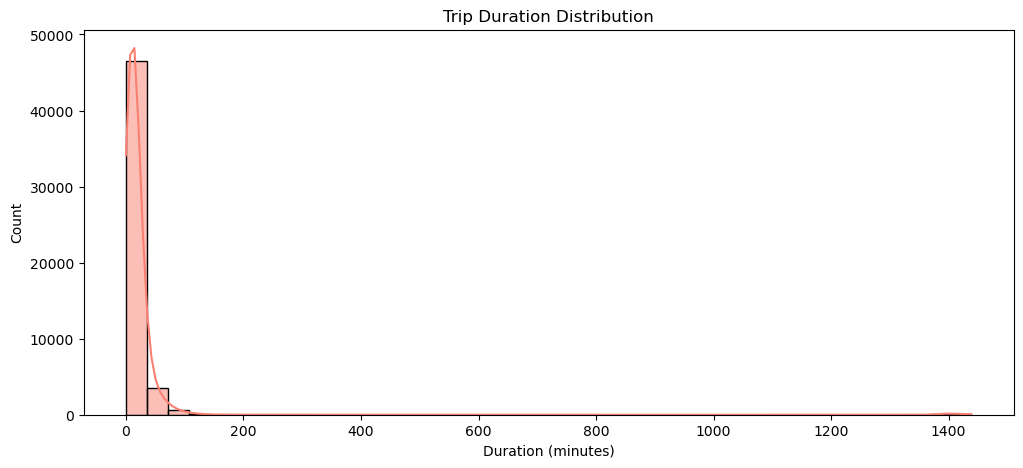

In [64]:
#trip distance and duration
plt.figure(figsize=(12,5))
sns.histplot(df['trip_distance'], bins=60, kde=True, color='skyblue')
plt.title('Trip Distance Distribution')
plt.xlabel('Distance (miles)')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['trip_duration_minutes'], bins=40, kde=True, color ='salmon')
plt.title("Trip Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.show()

In [66]:
#fare analysis
fare_cols =['fare_amount', 'tip_amount','total_amount']
df[fare_cols].describe()

,fare_amount,tip_amount,total_amount
count,51173.000000,51173.000000,51173.000000
mean,14.999228,1.379362,18.412681
std,14.581786,2.604919,16.248923
min,-150.000000,-1.140000,-150.300000
25%,7.000000,0.000000,9.300000
50%,10.500000,0.000000,13.560000
75%,17.000000,2.160000,21.300000
max,480.000000,87.710000,480.310000


In [70]:
(df['fare_amount']<0).sum()

141

In [71]:
(df['total_amount']<0).sum()

141

In [72]:
df[df['fare_amount']<0]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,start_hour,start_day,start_weekday,start_month,trip_duration_minutes
97,2.0,2021-07-01 06:07:26,2021-07-01 06:29:02,N,1.0,49,49,1.0,0.21,-12.0,...,-0.3,-12.80,4.0,1.0,0.0,6,1,Thursday,7,21.600000
754,2.0,2021-07-01 12:38:55,2021-07-01 12:43:19,N,1.0,17,17,5.0,0.44,-4.5,...,-0.3,-5.30,3.0,1.0,0.0,12,1,Thursday,7,4.400000
894,2.0,2021-07-01 13:13:03,2021-07-01 13:13:20,N,1.0,193,193,1.0,0.00,-2.5,...,-0.3,-3.96,3.0,1.0,0.0,13,1,Thursday,7,0.283333
1036,2.0,2021-07-01 15:40:54,2021-07-01 15:42:17,N,1.0,193,193,1.0,0.00,-3.0,...,-0.3,-4.94,3.0,1.0,0.0,15,1,Thursday,7,1.383333
1254,2.0,2021-07-01 16:30:21,2021-07-01 16:30:34,N,1.0,74,74,1.0,0.05,-2.5,...,-0.3,-4.30,3.0,1.0,0.0,16,1,Thursday,7,0.216667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48464,2.0,2021-07-30 14:33:19,2021-07-30 14:34:27,N,1.0,42,42,1.0,0.26,-3.0,...,-0.3,-3.80,3.0,1.0,0.0,14,30,Friday,7,1.133333
48826,2.0,2021-07-30 18:03:10,2021-07-30 18:04:26,N,1.0,7,7,1.0,0.02,-3.0,...,-0.3,-4.80,3.0,1.0,0.0,18,30,Friday,7,1.266667
49926,2.0,2021-07-31 10:44:07,2021-07-31 10:45:01,N,1.0,196,196,2.0,0.07,-2.5,...,-0.3,-3.30,3.0,1.0,0.0,10,31,Saturday,7,0.900000
50031,2.0,2021-07-31 11:49:20,2021-07-31 11:50:20,N,1.0,193,193,1.0,0.00,-2.5,...,-0.3,-3.30,3.0,1.0,0.0,11,31,Saturday,7,1.000000


In [78]:
df = df[(df["fare_amount"] >=0) & (df['total_amount']>=0)]

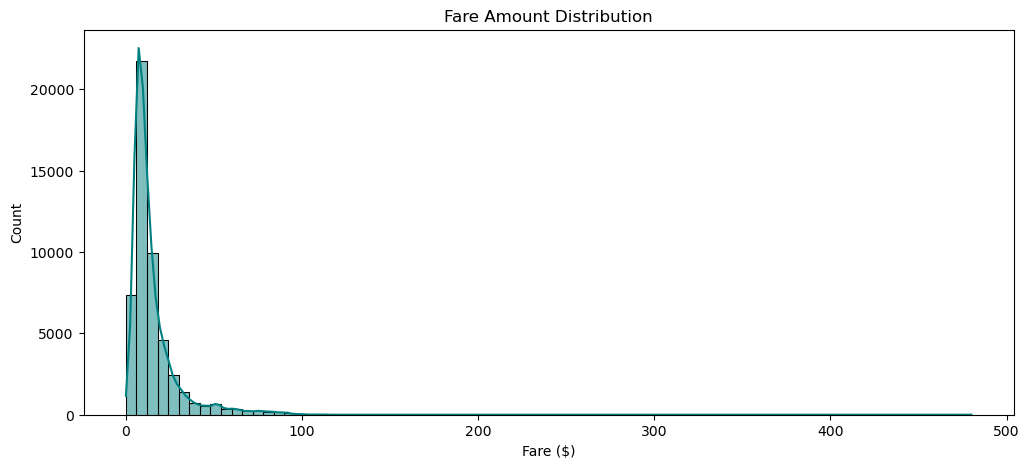

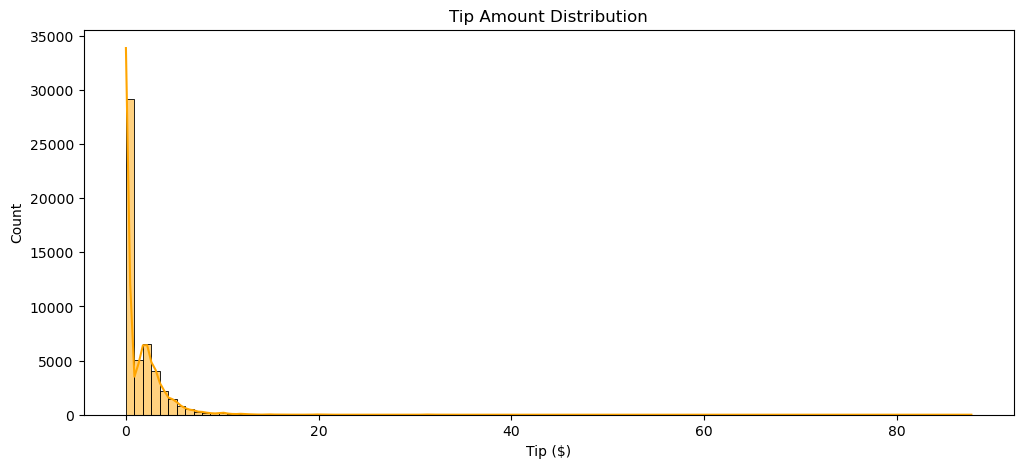

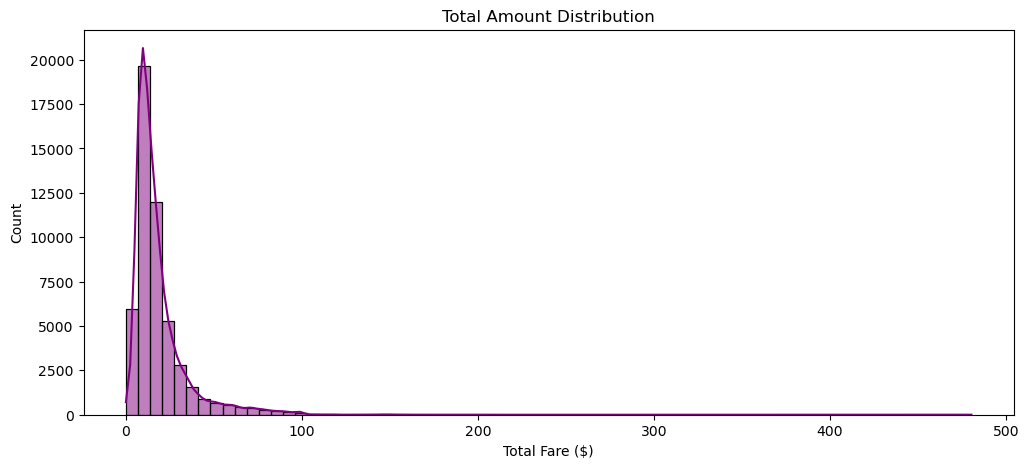

In [85]:
#fare distribution plots
plt.figure(figsize=(12,5))
sns.histplot(df['fare_amount'], bins=80, kde=True, color='teal')
plt.title('Fare Amount Distribution')
plt.xlabel('Fare ($)')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['tip_amount'], bins=100, kde=True, color ='orange')
plt.title("Tip Amount Distribution")
plt.xlabel("Tip ($)")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['total_amount'], bins=70, kde=True, color ='purple')
plt.title("Total Amount Distribution")
plt.xlabel("Total Fare ($)")
plt.show()


In [86]:
#passenger analysis
passenger_counts = df['passenger_count'].value_counts().sort_index()
passenger_counts

passenger_count
0.0        56
1.0     44009
2.0      3905
3.0       625
4.0       181
5.0      1235
6.0      1018
7.0         2
32.0        1
Name: count, dtype: int64

In [89]:
df = df[df['passenger_count']>0]

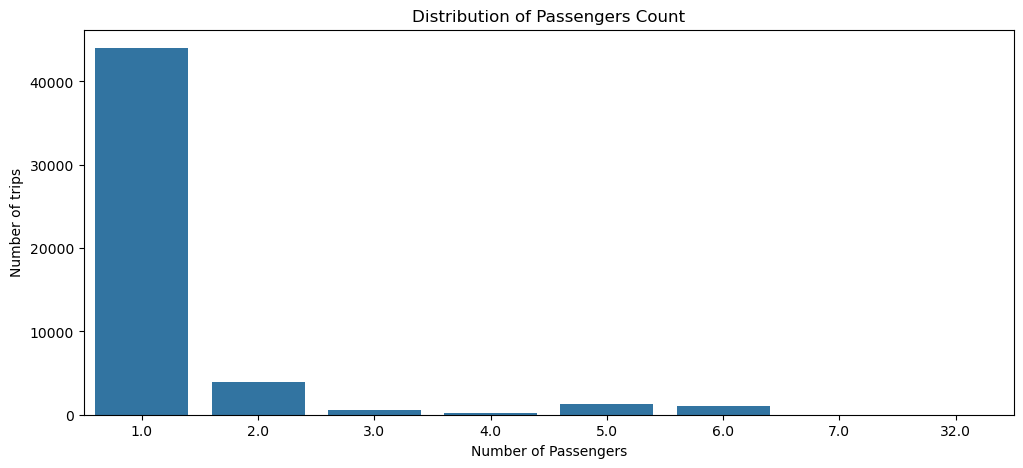

In [90]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='passenger_count')
plt.title('Distribution of Passengers Count')
plt.ylabel('Number of trips')
plt.xlabel('Number of Passengers')
plt.show()

In [91]:
passenger_fare = df.groupby('passenger_count')['fare_amount'].mean()

passenger_fare

passenger_count
1.0     14.903393
2.0     18.220876
3.0     17.192800
4.0     17.959945
5.0     12.530202
6.0     10.695972
7.0     38.500000
32.0    52.000000
Name: fare_amount, dtype: float64

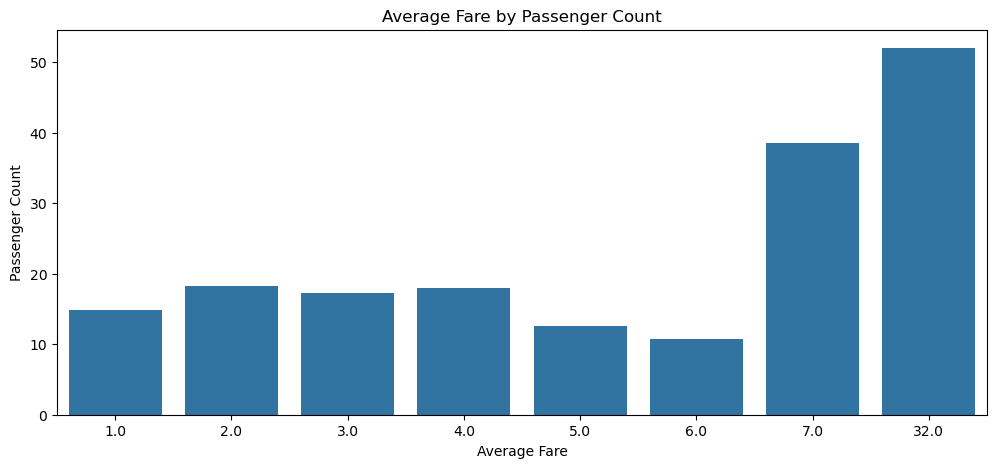

In [92]:
plt.figure(figsize=(12,5))
sns.barplot(x=passenger_fare.index,y=passenger_fare.values)
plt.title('Average Fare by Passenger Count')
plt.ylabel('Passenger Count')
plt.xlabel('Average Fare')
plt.show()

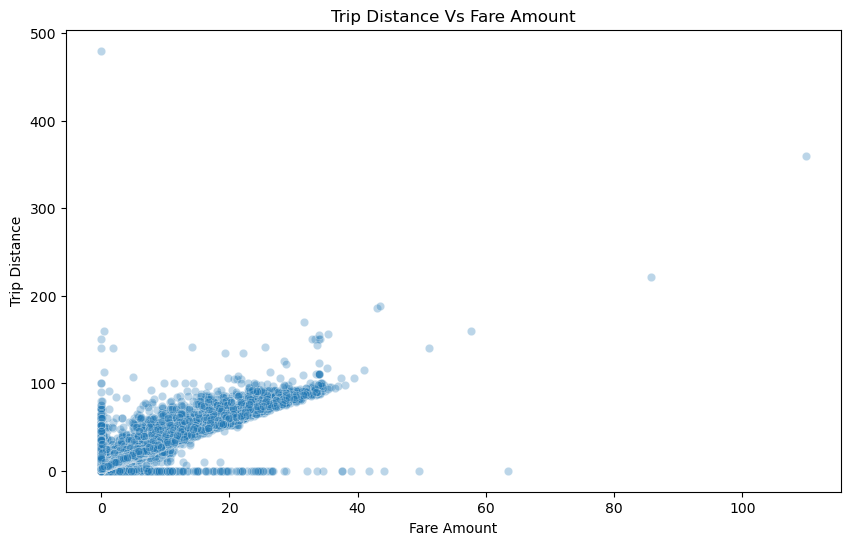

In [94]:
#distance vs fare
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='trip_distance',
    y='fare_amount',
    alpha=0.3
)
plt.title('Trip Distance Vs Fare Amount')
plt.ylabel('Trip Distance')
plt.xlabel('Fare Amount')
plt.show()